## Case Study for Statistical Methods

In [1]:
pip install panadas numpy matplotlib seaborn scipy statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as ols
from statsmodels.multivariate.manova import MANOVA

## Chi Square Test

#### Assume expected distribution is 50% vegetarian and 50% non-vegetarian. Here tried to test if sample data matches this distribution.(Goodness of fit model)

In [5]:
import numpy as np
from scipy.stats import chisquare

# Hypothetical observed frequencies
observed_frequencies =np.array([30,70]) # eg, 50 vegetarians and 30 non-vegetarians

# Expected frequencies [assuming 50-50 distribution]
total_meals=observed_frequencies.sum()
expected_frequencies = np.array([total_meals/2, total_meals/2]) # [40, 40]

# Perform chi-square test
chi2_statistic, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

# Print results
print(f"Chi-square statistic: {chi2_statistic}")
print(f"P-value: {p_value}")

# print results with if else statement
if p_value < 0.05:
    print(f"Reject the null hypothesis, there is a significant difference between groups")
else:
    print(f"Fail to reject the null hypothesis, there is no significant difference between groups")

Chi-square statistic: 16.0
P-value: 6.334248366623988e-05
Reject the null hypothesis, there is a significant difference between groups


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

from scipy.stats import chi2_contingency


# data load
df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
# Create a contingency table

contingency_table = pd.crosstab(df['sex'], df['smoker'])
contingency_table

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [12]:
contingency_table = pd.crosstab(df['sex'], df['day'])
contingency_table

day,Thur,Fri,Sat,Sun
sex,,,,
Male,30,10,59,58
Female,32,9,28,18


In [14]:
contingency_table = pd.crosstab(df['smoker'], df['time'])
contingency_table

time,Lunch,Dinner
smoker,,
Yes,23,70
No,45,106


In [13]:
# Perform chi-square test
chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)

# output results

print(f"Chi-square statistic: {chi2_statistic}")
print(f"P-value: {p_value}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:/n", np.array(expected))

# print results with if else statement
if p_value < 0.05:
    print('Reject the null hypothesis, there is a significant association between the groups')

else:
    print('Fail to reject the null hypothesis, there is no significant association between the groups')
    

Chi-square statistic: 13.22200137240661
P-value: 0.004180302092822257
Degrees of freedom: 3
Expected frequencies:/n [[39.89344262 12.22540984 55.9795082  48.90163934]
 [22.10655738  6.77459016 31.0204918  27.09836066]]
Reject the null hypothesis, there is a significant association between the groups


##T-Test
# One Sample T-Test


In [15]:
# one sample ttest
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# data load
df=sns.load_dataset('tips')
df.head()




,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [20]:
# one sample ttest
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# data load
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='total_bill', ylabel='Count'>

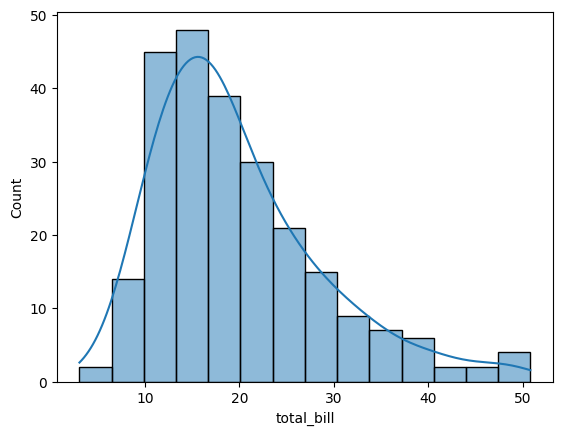

In [16]:
sns.histplot(df['total_bill'], kde=True)

<Axes: xlabel='tip', ylabel='Count'>

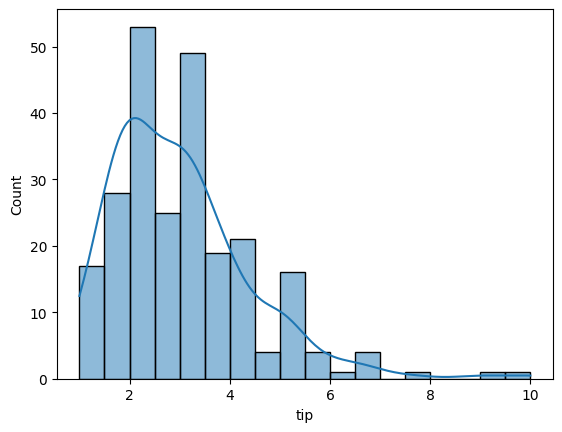

In [18]:
sns.histplot(df['tip'], kde=True)

In [22]:
# Impute null values 
df['age']=df['age'].fillna(df['age'].median())
df['fare']=df['fare'].fillna(df['fare'].median())


In [19]:
# shapiro test for normal distribution
statistics,p=stats.shapiro(df['total_bill'])

# print results based on p value and if else statement
if p > 0.05:
    print(' reject the null hypothesis, data is not normally distributed')
else:
    print('Fail to reject the null hypothesis, data is normally distributed')


Fail to reject the null hypothesis, data is normally distributed


In [28]:
df['age'].mean()

np.float64(29.36158249158249)

In [27]:
#mua=35
# is there difference between the ages of people and mua
statistics,p=stats.ttest_1samp(df['age'],30)

# print result based on p value and if else statement
if p < 0.05:
    print('Reject the null hypothesis, there is a significant difference between the groups')
else:
    print('Fail to reject the null hypothesis, there is no significant difference between the groups')

Fail to reject the null hypothesis, there is no significant difference between the groups


## 2. Two sample independent T-Test

In [ ]:
# lets run the two sample ttest on age based on male and female in titanic dataset
age_male=df[df['sex']=='male']['age']
age_female=df[df['sex']=='female']['age']
statistics,p=stats.ttest_ind(age_male, age_female)

# print result based on p value and if else statement
if p < 0.05:
    print(f'Reject the null hypothesis,because p-value: {p} there is a significant difference between the ages of male and female passengers')
else:
    print(f'Fail to reject the null hypothesis, because p-value: {p} there is no significant difference between the ages of male and female passengers')

In [ ]:

stats.ttest_ind(df[df['sex']=='male']['age'], df[df['sex']=='female']['age'])

## Anova

In [29]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### H0: There is no difference.
### H1. There is difference between ages of first,second and third class passangers

In [31]:
df[['age','class']].head()

,age,class
0,22.0,Third
1,38.0,First
2,26.0,Third
3,35.0,First
4,35.0,Third


<Axes: xlabel='pclass', ylabel='age'>

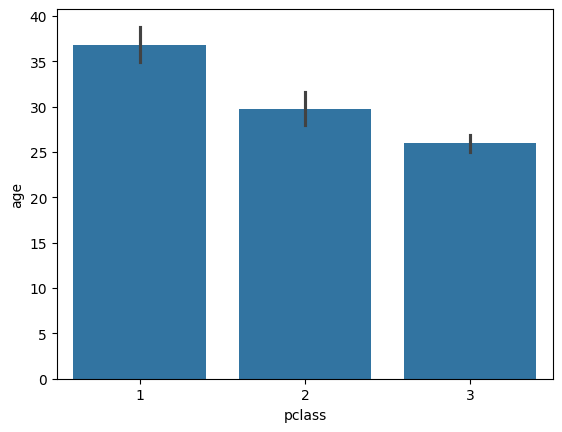

In [34]:
sns.barplot(x='pclass', y='age', data=df)

<Axes: xlabel='age', ylabel='Count'>

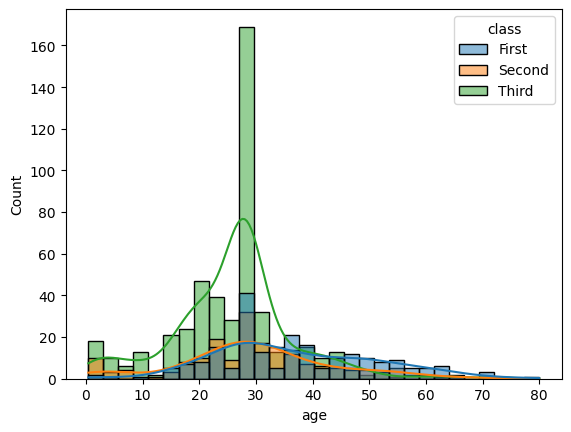

In [38]:
# hist plot with pclass grouping
sns.histplot(df,x='age',hue='class',kde=True)
             

In [ ]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ANOVA test to compare the mean ages of passengers across different classes (Pclass)

model=ols('age ~ pclass', data=df).fit()
anova_table=sm.stats.anova_lm(model, typ=2)
print(anova_table)

# print result based on p value and if else statement
if anova_table['PR(>F)'][0] < 0.05:
    print(f'Reject the null hypothesis, because p-value: {anova_table["PR(>F)"][0]} there is a significant difference in mean ages across different classes')
else:
    print(f'Fail to reject the null hypothesis, because p-value: {anova_table["PR(>F)"][0]} there is no significant difference in mean ages across different classes')

    

                 sum_sq     df           F        PR(>F)
pclass     17429.695048    1.0  116.122704  1.558883e-25
Residual  133436.428421  889.0         NaN           NaN


## Two way Anova

In [39]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# stats models

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Anova test for age and class
# model=ols('age ~ pclass + who +pclass:who', data=df).fit()
model=ols('age ~ pclass * who', data=df).fit()
anova_table=sm.stats.anova_lm(model, typ=2)
print(anova_table)

                  sum_sq     df           F        PR(>F)
who         42921.503765    2.0  213.017404  3.006796e-76
pclass      11863.085431    1.0  117.751870  7.658356e-26
pclass:who   1354.296985    2.0    6.721312  1.267414e-03
Residual    89160.627671  885.0         NaN           NaN


In [43]:
# stats models

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Anova test for age and class
# model=ols('age ~ pclass + who +pclass:who', data=df).fit()
model=ols('age ~ sex * who', data=df).fit()
anova_table=sm.stats.anova_lm(model, typ=2)
print(anova_table)

                sum_sq     df             F        PR(>F)
sex                NaN    1.0           NaN           NaN
who       1.294561e-10    2.0  5.611466e-13  9.999994e-01
sex:who   5.233208e+04    2.0  2.268412e+02  8.119221e-46
Residual  1.023151e+05  887.0           NaN           NaN


c:\Users\Aksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
c:\Users\Aksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
c:\Users\Aksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\Aksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full 

<Axes: xlabel='who', ylabel='age'>

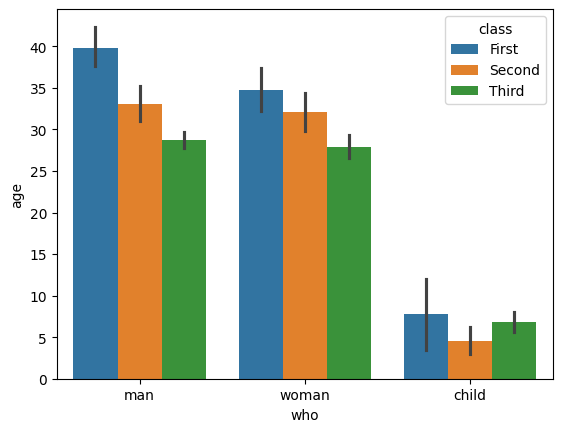

In [46]:
sns.barplot(df,x='who',y='age',hue='class')

### Correlation

In [47]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: >

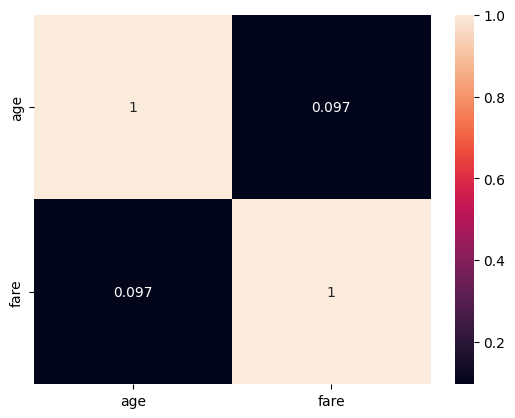

In [49]:
# create heatmap for correlation
sns.heatmap(df[['age','fare']].corr(), annot=True)

In [53]:
age_female=df[df['sex']=='female']['age']
age_male=df[df['sex']=='male']['age']

# make dataset for age_male and age_female
data=pd.DataFrame(age_female,age_male)
data.head()


,age
age,
22.0,15.0
35.0,NaN
28.0,28.0
54.0,NaN
2.0,26.0


In [ ]:
sns.scatterplot(x=age_female, y=age_male)

In [54]:
# Tips and correlation
tips=sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [58]:
tips['total_bill'].corr(tips['tip'])

np.float64(0.6757341092113645)

<Axes: xlabel='total_bill', ylabel='tip'>

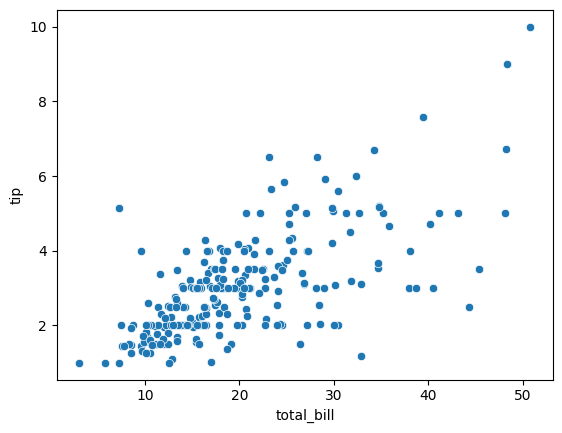

In [65]:
sns.scatterplot(x='total_bill', y='tip', data=tips)


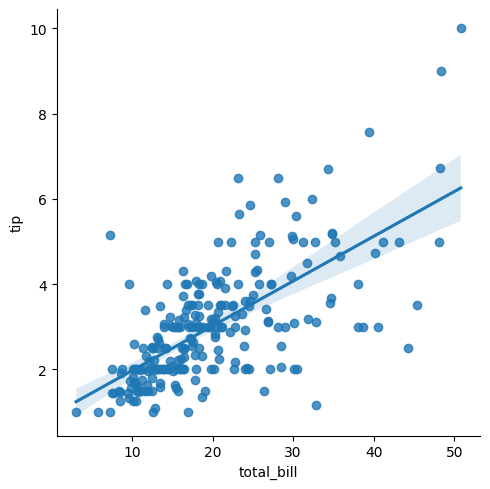

In [66]:
sns.lmplot(x='total_bill', y='tip', data=tips)

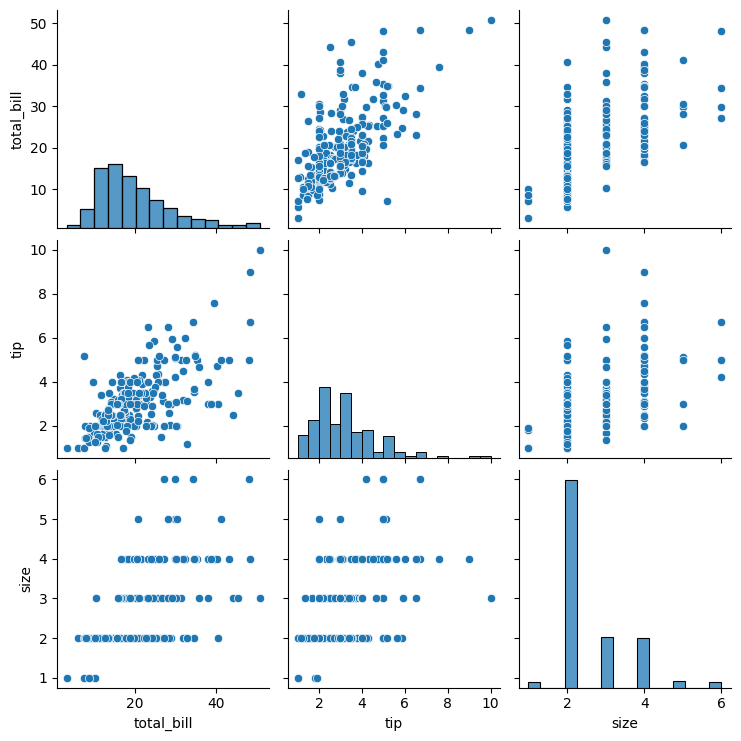

In [ ]:
sns.pairplot(tips) # only on continuous variable

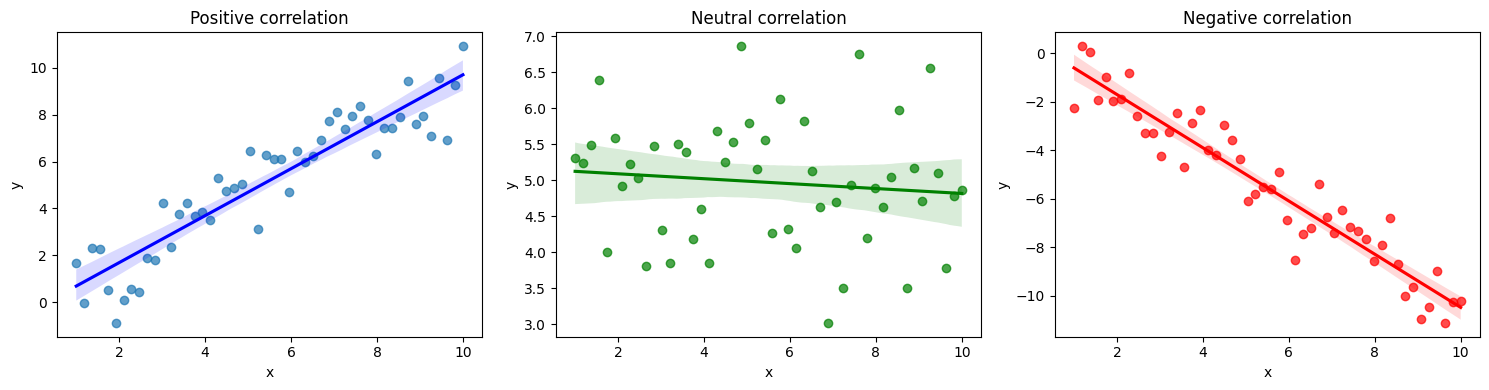

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Example data
x = np.linspace(1, 10, 50)
y_pos = x + np.random.normal(0, 1, 50)
y_neutral = np.random.normal(5, 1, 50)
y_neg = -x + np.random.normal(0, 1, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Positive correlation
axes[0].scatter(x, y_pos, alpha=0.7)
sns.regplot(x=x, y=y_pos, ax=axes[0], scatter=False, color='blue')
axes[0].set_title('Positive correlation')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Neutral correlation
axes[1].scatter(x, y_neutral, alpha=0.7, color='green')
sns.regplot(x=x, y=y_neutral, ax=axes[1], scatter=False, color='green')
axes[1].set_title('Neutral correlation')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# Negative correlation
axes[2].scatter(x, y_neg, alpha=0.7, color='red')
sns.regplot(x=x, y=y_neg, ax=axes[2], scatter=False, color='red')
axes[2].set_title('Negative correlation')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')

plt.tight_layout()
plt.show()


In [64]:
#plotting the three types of correlation in one figure
plt.figure(figsize=(15,5))

# Positive correlation between total bill and tip, as total bill increases tip also increases
plt.Subplot(1,3,1)
plt.scatter(x,y_pos,alpha=0.7)
plt.title('Positive correlation' )
plt.xlabel('x')
plt.ylabel('y')

# neutral correlation between total bill and tip, as total bill increases tip also increases
plt.Subplot(1,3,2)
plt.scatter(x_neutral,y_neutral,alpha=0.7,color='green')
sns.lmplot(x_neutral, y_neutral)
plt.title('Neutral correlation' )
plt.xlabel('x')
plt.ylabel('y')

# negative correlation between total bill and tip, as total bill increases tip also increases
plt.Subplot(1,3,3)
plt.scatter(x,y_neg,alpha=0.7,color='red')
plt.title('Negative correlation' )
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

<Figure size 1500x500 with 0 Axes>

In [ ]:
cd Desktopcd